# Projet Airbnb - Prédiction de prix

**Fait par :** Akihito RAFFIN et Henri PORTIER                                                            
**Classe :** TDQ

## 1. Importation et Chargement des données

In [25]:
#Importation des libraires 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

#Importation des modèles 
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_theme(style='whitegrid', palette='muted')


RANDOM_STATE = 0

In [26]:
#Chargement des données
train = pd.read_csv('airbnb_train.csv')
test = pd.read_csv('airbnb_test.csv')
print(f"Taille du fichier train : {train.shape}")
print(f"Taille du fichier test : {test.shape}")

Taille du fichier train : (22234, 28)
Taille du fichier test : (51877, 27)


## 2. Exploration qualitative des données

On explore les logements Airbnb pour comprendre ce qui influence le prix. Cette section vise à comprendre la structure des données, les distributions et les relations avec la variable cible log_price. 
Cela va nous permettre par la suite de choisir les bonnes features pour notre modèle de prédiction.

### 2.1) Vue d'ensemble 

On affiche les premières lignes pour avoir un aperçu des colonnes et des types de données.

In [27]:
train.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [28]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_verified  22178 non-null

Le dataset contient 22 234 lignes et 28 colonnes. On identifie plusieurs types de données (Numériques,texte brut, catégories).

On observe que plusieurs colonnes ont des valeurs manquantes ("bathrooms", "first_review", "host_has_profile_pic",etc.). 
Au lieu de supprimer les lignes qui ont des NaN (on perdrait beaucoup de données), on traitera ces valeurs manquantes dans la partie feature engineering en les remplaçant par la médiane.

In [29]:
train.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,2.223400e+04,22234.000000,22234.000000,22183.000000,22234.000000,22234.000000,22234.000000,17256.000000,22208.000000,22199.000000
mean,1.122269e+07,4.783481,3.155573,1.236037,38.462971,-92.269305,20.670774,94.069077,1.264769,1.711473
std,6.080480e+06,0.718758,2.143870,0.586246,3.071679,21.670081,37.183731,7.782235,0.852819,1.254903
min,3.362000e+03,2.302585,1.000000,0.000000,33.339002,-122.510940,0.000000,20.000000,0.000000,0.000000
25%,6.202924e+06,4.317488,2.000000,1.000000,34.136082,-118.340633,1.000000,92.000000,1.000000,1.000000
50%,1.217425e+07,4.700480,2.000000,1.000000,40.662632,-76.994944,6.000000,96.000000,1.000000,1.000000
75%,1.639502e+07,5.220356,4.000000,1.000000,40.746358,-73.954599,23.000000,100.000000,1.000000,2.000000
max,2.120450e+07,7.600402,16.000000,8.000000,42.390248,-70.989359,505.000000,100.000000,10.000000,18.000000


Quelques observations : 
- **log_price** varie de 2.30 à 7.60, avec une médiane à 4.70 et une moyenne à 4.78. La légère différence entre médiane et moyenne indique quelques logements très chers qui tirent la moyenne vers le haut. La médiane est insensible aux valeurs extrêmes donc lorsque moyenne>médiane, cela veut dire qu'il y a des logements très chers qui tirent la moyenne vers le haut.
- **accommodates** va de 1 à 16 personnes, avec une médiane de 2. On peut en déduire que la majorité des logements sont pour 1 ou 2 personnes.
- **review_scores_rating** a une médiane à 96/100. Les notes sont globalement très élevées et nous permet pas de bien distinguer les logements chers des logements pas chers.


### 2.2) Valeurs manquantes


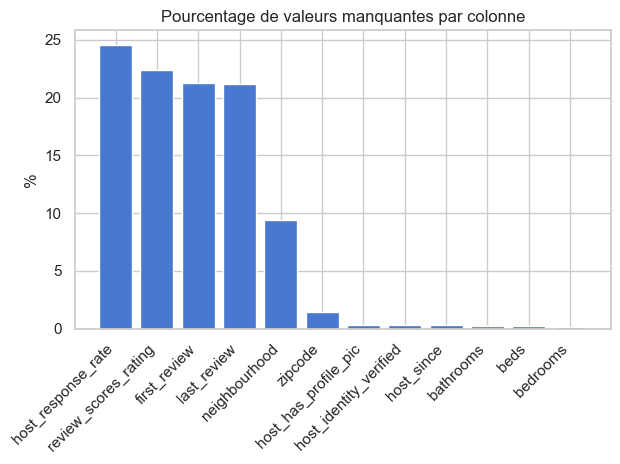

                        Valeurs manquantes  % manquants
host_response_rate                    5475         24.6
review_scores_rating                  4978         22.4
first_review                          4725         21.3
last_review                           4716         21.2
neighbourhood                         2086          9.4
zipcode                                303          1.4
host_has_profile_pic                    56          0.3
host_identity_verified                  56          0.3
host_since                              56          0.3
bathrooms                               51          0.2
beds                                    35          0.2
bedrooms                                26          0.1


In [30]:
missing = train.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

plt.bar(missing_pct.index, missing_pct.values)
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.ylabel('%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Valeurs manquantes' : missing, '% manquants' : missing_pct}))

On remarque qu'il y a 5 colonnes qui ont beaucoup de valeurs manquantes. On ne supprimera pas ces lignes car cela représenterait une perte trop importante de données. On remplacera les valeurs manquantes numériques par la **médiane** et les valeurs catégorielles par le **mode** (valeur la plus fréquente dans une colonne) lors du feature engineering.

### 2.3) Distribution de la variable cible (log_price)

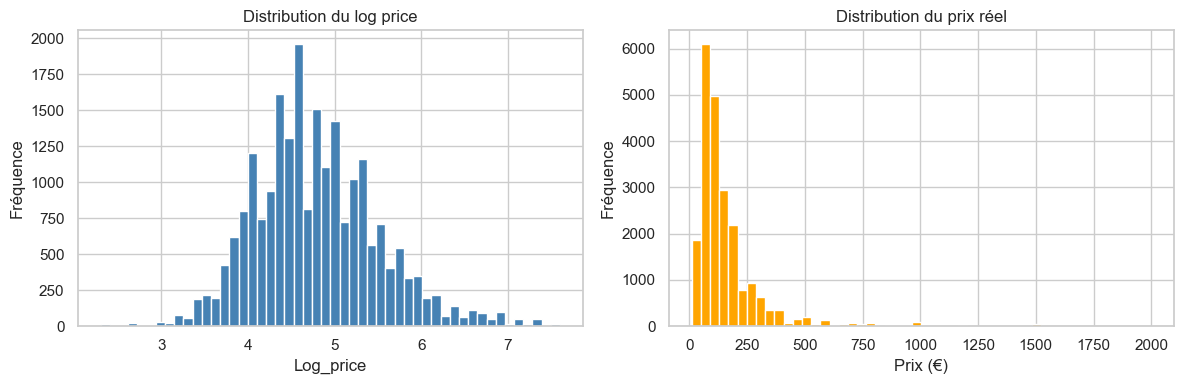

In [31]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

#Distribution log_price
axes[0].hist(train['log_price'],bins=50, color = 'steelblue', edgecolor = 'white')
axes[0].set_title('Distribution du log price')
axes[0].set_xlabel('Log_price')
axes[0].set_ylabel('Fréquence')

#Distribution prix réel 
axes[1].hist(np.exp(train['log_price']),bins=50, color = 'orange', edgecolor = 'white')
axes[1].set_title('Distribution du prix réel')
axes[1].set_xlabel('Prix (€)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()


On remarque que la distribution du prix est très asymétrique dans le cas de la distribution du prix réel. L'application du logarithme permet d'obtenir une distribution proche d'une loi normale, on transforme ici une variable très étalée en une variable symétrique. Cela va faciliter l'entrainement des modèles de régression et va rendre l'apprentissage du modèle beaucoup plus stable et plus précis.

### 2.4) Prix par ville

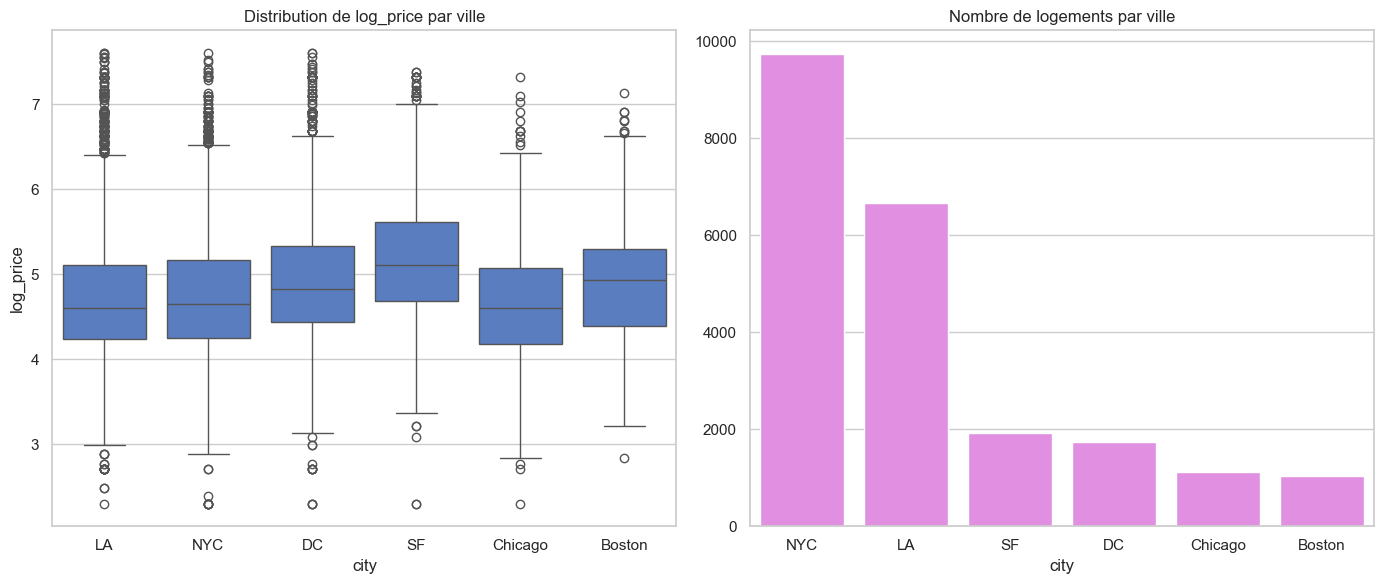

In [32]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(data=train,x='city',y='log_price',ax=axes[0])
axes[0].set_title('Distribution de log_price par ville')

data = train['city'].value_counts()
sns.barplot(x=data.index,y=data.values, color='violet',ax=axes[1])
axes[1].set_title("Nombre de logements par ville")

plt.tight_layout()
plt.show()

D'abord, on a affiché la répartition des prix par ville avec un boxplot. Nous avons utilisé la médiane plutôt que la moyenne pour ne pas être trompé par les logements ultra-luxueux. Cela nous a permis de confirmer que le prix varie énormément selon la ville, et donc que cette variable est cruciale pour notre prédiction.

La moyenne est influencée par les prix de luxe alors que la médiane non, ce qui est beaucoup plus représentatif pour un utilisateur airbnb.
Les outliners nous permettent de voir si une ville a énormément de logements "hors de prix" par rapport aux autres.

On a choisi des boxplots pour comparer les prix entre les villes car ils permettent de visualiser non seulement le prix médian, mais aussi la variabilité des prix au sein de chaque ville. On remarque par exemple que certaines villes comme San Francisco ont une médiane beaucoup plus élevée, ce qui confirme que la variable city est un prédicteur essentiel pour notre modèle.


### 2.5) Prix par type de logement

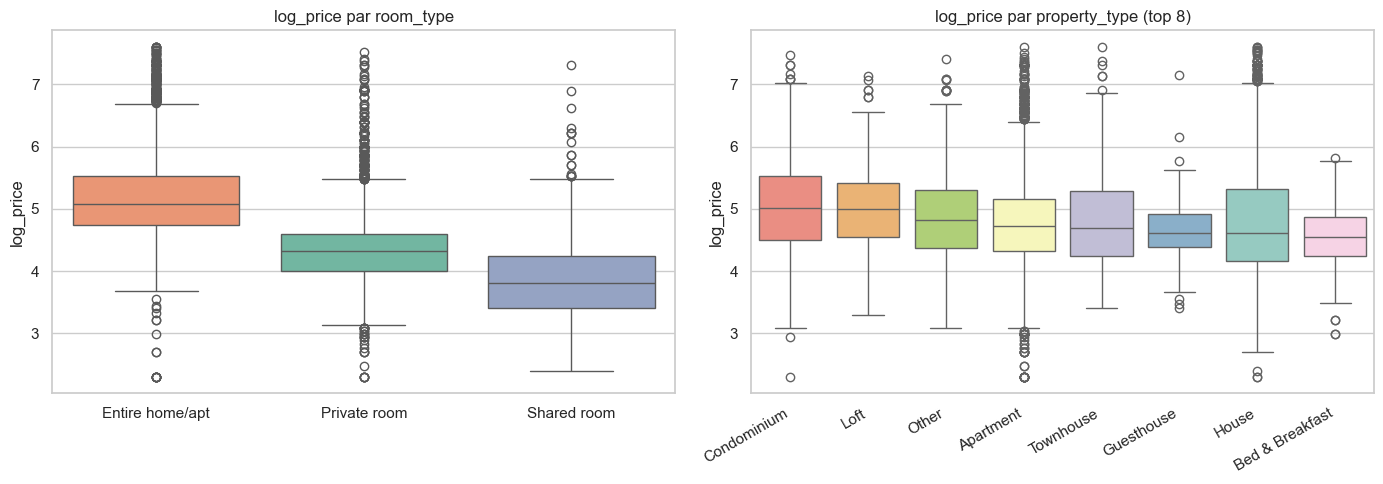

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# room_type (3 catégories de room)
room_order = train.groupby('room_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='room_type', y='log_price', order=room_order, ax=axes[0], palette='Set2',hue='room_type', legend=False)
axes[0].set_title('log_price par room_type')
axes[0].set_xlabel('')



# prperty_type (top 8 pour la lisibilité)
top_props = train['property_type'].value_counts().head(8).index  
df_top = train[train['property_type'].isin(top_props)]  

prop_order = df_top.groupby('property_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='property_type', y='log_price', order=prop_order, ax=axes[1], palette='Set3',hue='property_type', legend=False)
axes[1].set_title('log_price par property_type (top 8)')
axes[1].set_xlabel('')
plt.xticks(rotation=30,ha='right')

plt.tight_layout()
plt.show()

Le type de chambre (**room_type**) est l'un des prédicteurs les plus forts du prix :
- **Entire home/apt** : médiane à 5.08 (logement entier, le plus cher)
- **Private room** : médiane à 4.32 (environ 2x moins cher qu'un logement entier)
- **Shared room** : médiane à 3.81 (le moins cher, chambre partagée avec d'autres locataires)

L'écart entre Entire home et Shared room représente un facteur ~3.5x sur le prix réel. Cette variable sera donc une feature essentielle dans nos modèles.

Du côté du **property_type**, les Condominiums (médiane 5.01) et Lofts (médiane 5.00) sont les plus chers, devant les Apartments (4.73) et les Houses (4.61). Ces différences sont moins marquées que pour **room_type**.

Cette variable sera donc moins discriminante.

### 2.6) Corrélations avec des variables numériques avec log_price

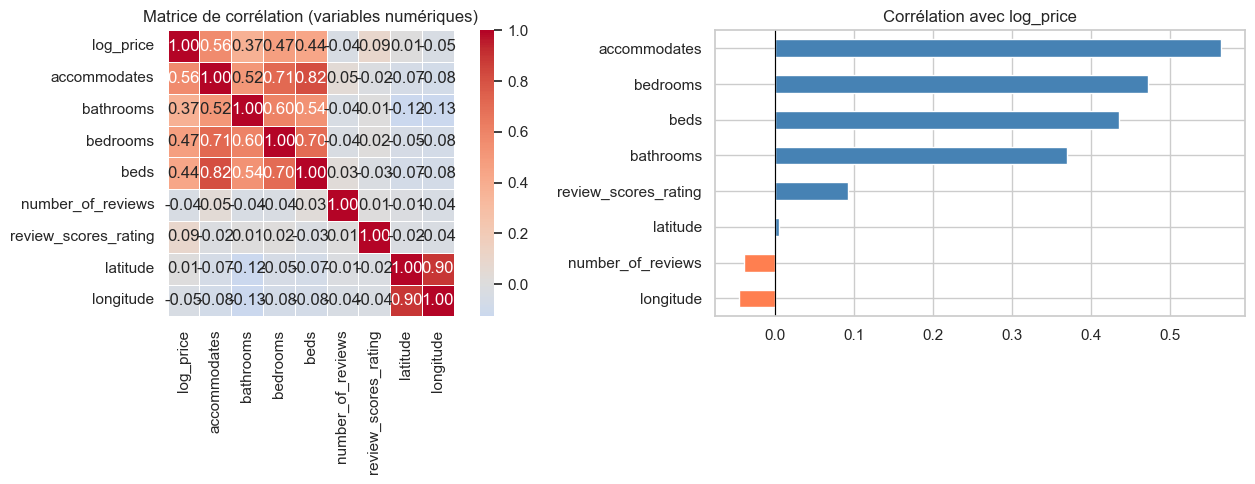

In [34]:
num_cols = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 
            'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude']

corr = train[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap corrélation (variables numériques seulement — lisible !)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Matrice de corrélation (variables numériques)')

# Corrélation avec log_price seulement
corr_target = corr['log_price'].drop('log_price').sort_values()
colors = ['coral' if v < 0 else 'steelblue' for v in corr_target]
corr_target.plot(kind='barh', ax=axes[1], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation avec log_price')

plt.tight_layout()
plt.show()

Moteurs du prix : Les variables liées à la capacité d'accueil (accommodates, bedrooms, bathrooms) sont les plus corrélées positivement avec log_price. La taille physique est le facteur déterminant.

Redondances (Multi-colinéarité) : La heatmap révèle de fortes corrélations entre beds, bedrooms et accommodates (jusqu'à 0.82). Ces variables partagent des informations similaires, ce qu'il faudra gérer lors du choix du modèle car si on lui donne trop d'informations qui disent la même chose, il peut devenir instable.

Réputation : Le score des avis (review_scores_rating) n'a quasiment aucun impact linéaire sur le prix.

### 2.7) Analyse des amenities

La colonne **amenities** est au format texte brut : {TV,"Wireless Internet",...}. On extrait les 30 amenities les plus fréquentes pour voir lesquelles sont corrélées au prix.

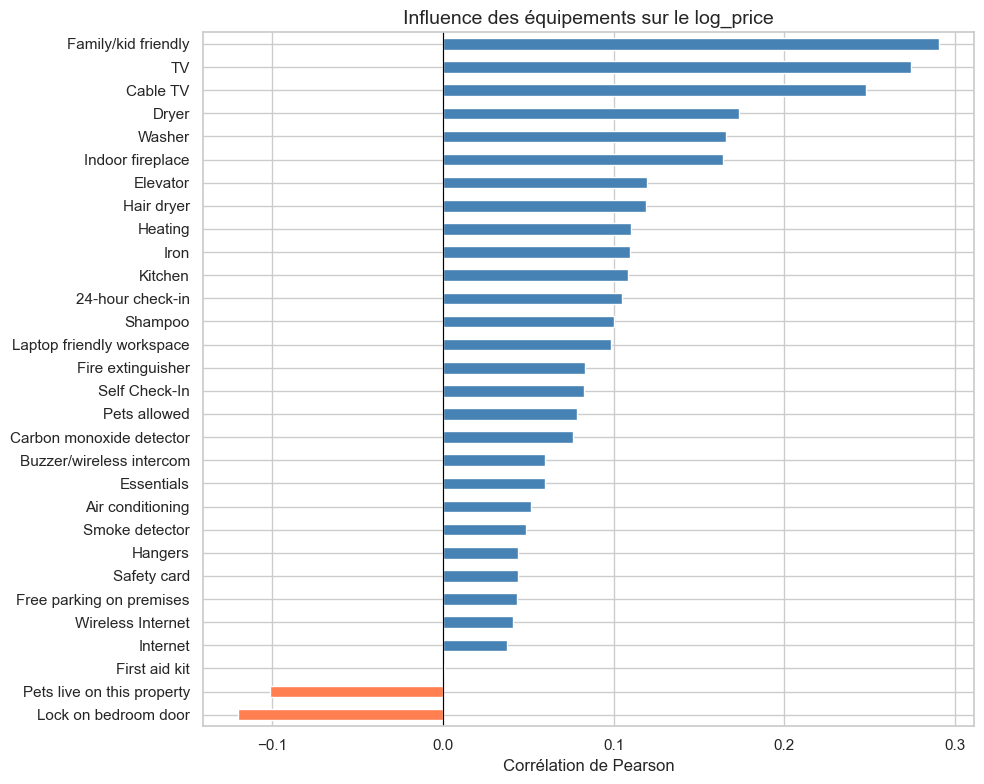

In [35]:
# 1. Extraction rapide des 30 amenities les plus fréquentes
all_am = [a.strip('"{ }') for row in train['amenities'] for a in row.split(',')]
top_amenities = [a for a, _ in Counter(all_am).most_common(35) if 'translation' not in a][:30] #on en prend 35 au cas où il y a des lignes d'erreurs

# 2. Calcul des corrélations sans créer de colonnes dans le DataFrame
corrs = {}
for am in top_amenities:
    # On crée une série de 0/1 temporaire pour calculer la corrélation
    has_am = train['amenities'].str.contains(am, regex=False)
    corrs[am] = train['log_price'].corr(has_am)

am_corr = pd.Series(corrs).sort_values()

# 3. Graphique
plt.figure(figsize=(10, 8))
am_corr.plot(kind='barh', color=['coral' if v < 0 else 'steelblue' for v in am_corr])
plt.axvline(0, color='black', lw=0.8)
plt.title('Influence des équipements sur le log_price', fontsize=14)
plt.xlabel('Corrélation de Pearson')
plt.tight_layout()

Cette analyse identifie quels équipements fréquents influencent réellement le **log_price** afin de cibler les variables utiles pour notre futur modèle.

* **Leviers de prix identifiés :** Le caractère "Family/kid friendly", la "TV (Cable TV)" et les équipements de logistique domestique ("Dryer", "Washer") présentent les plus fortes corrélations positives. Ils marquent une nette différence de standing.
* **Signaux négatifs :** La présence d'un "Lock on bedroom door" (verrou sur la porte de la chambre) est corrélée négativement au prix. Cela indique souvent des chambres partagées ou des logements moins luxueux.
* **Utilité pour la Feature Selection :** - Nous éliminerons les variables à corrélation quasi-nulle (ex: "Internet", "First aid kit") qui n'apportent que du "bruit".
    - Nous conserverons les équipements du haut du graphique qui aideront le modèle à mieux prédire les tarifs élevés.

## 3) Feature engineering

On construit ici toutes les features à partir des données brutes.
Cette étape transforme les données brutes en indicateurs numériques exploitables par nos modèles.

. Points clés :

Extraction : Transformation de la colonne amenities en score numérique et colonnes binaires.

Dates : Conversion des dates en "ancienneté" (nombre de jours).

Encodage : Passage des variables textuelles (city, room_type) en nombres via un mapping fixe.

Rigueur : Utilisation d'un dictionnaire de statistiques (train_stats) pour appliquer les mêmes transformations (médianes, catégories) sur le Train et le Test, évitant ainsi toute "fuite de données" (Data Leakage).


In [36]:
def build_features(df, top_amenities, stats=None):
    """
    df : DataFrame à transformer
    top_amenities : liste des amenities fréquentes
    stats : dictionnaire contenant les médianes et mappings du train (None si c'est le train)
    """
    df = df.copy()
    is_train = stats is None
    if is_train:
        stats = {'medians': {}, 'mappings': {}}

    # --- 1. Amenities ---
    for am in top_amenities:
        col = f'has_{am.lower().replace(" ", "_").replace("/", "_")}'
        df[col] = df['amenities'].apply(lambda x: 1 if am in str(x) else 0)
    df['n_amenities'] = df['amenities'].apply(lambda x: len(str(x).split(',')))

    # --- 2. Encodage Ordinal (Statique) ---
    room_map = {'Shared room': 0, 'Private room': 1, 'Entire home/apt': 2}
    df['room_type_enc'] = df['room_type'].map(room_map).fillna(-1)
    
    cancel_map = {'flexible': 0, 'moderate': 1, 'strict': 2, 'super_strict_30': 3, 'super_strict_60': 4}
    df['cancellation_enc'] = df['cancellation_policy'].map(cancel_map).fillna(-1)

    # --- 3. Encodage Catégoriel (Sécurisé) ---
    for col in ['city', 'bed_type']:
        if is_train:
            # On crée un mapping unique basé sur l'ordre alphabétique
            unique_vals = sorted(df[col].astype(str).unique())
            stats['mappings'][col] = {val: i for i, val in enumerate(unique_vals)}
        
        df[f'{col}_enc'] = df[col].astype(str).map(stats['mappings'][col]).fillna(-1)

    # Property type avec regroupement
    top_props = ['Apartment', 'House', 'Condominium', 'Townhouse', 'Loft']
    df['prop_clean'] = df['property_type'].apply(lambda x: x if x in top_props else 'Other')
    if is_train:
        unique_props = sorted(df['prop_clean'].unique())
        stats['mappings']['prop'] = {val: i for i, val in enumerate(unique_props)}
    df['property_type_enc'] = df['prop_clean'].map(stats['mappings']['prop']).fillna(-1)

    # --- 4. Dates & Ratio ---
    ref_date = pd.Timestamp('2018-01-01') # Date un peu après le dataset
    for col in ['host_since', 'first_review', 'last_review']:
        df[f'{col}_days'] = (ref_date - pd.to_datetime(df[col], errors='coerce')).dt.days
    
    # Nouvelle feature : Ratio chambres/capacité
    df['beds_per_accommodates'] = df['beds'] / (df['accommodates'] + 1)

    # --- 5. Nettoyage Taux de réponse ---
    df['response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False)
    df['response_rate'] = pd.to_numeric(df['response_rate'], errors='coerce')

    # --- 6. Gestion des NaN (Basée sur le Train) ---
    num_cols = ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating', 
                'response_rate', 'host_since_days', 'first_review_days', 'last_review_days', 'beds_per_accommodates']
    
    for col in num_cols:
        if is_train:
            stats['medians'][col] = df[col].median()
        df[col] = df[col].fillna(stats['medians'][col])

    return df, stats

In [37]:
# 1. On transforme le TRAIN et on récupère les stats (médianes, etc.)
train_fe, train_stats = build_features(train, top_amenities)

# 2. On transforme le TEST en lui passant les stats du TRAIN
test_fe, _ = build_features(test, top_amenities, stats=train_stats)

# 3. Définition des colonnes finales
AMENITY_COLS = [f'has_{am.lower().replace(" ", "_").replace("/", "_")}' for am in top_amenities]
FEATURE_COLS = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'beds_per_accommodates',
    'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude',
    'n_amenities', 'room_type_enc', 'cancellation_enc', 'city_enc',
    'property_type_enc', 'bed_type_enc', 'response_rate',
    'host_since_days', 'first_review_days', 'last_review_days'
] + AMENITY_COLS

X = train_fe[FEATURE_COLS]
y = train_fe['log_price']
X_test_final = test_fe[FEATURE_COLS]

# --- VÉRIFICATION DE SÉCURITÉ ---
print(f"Check des valeurs manquantes dans X : {X.isnull().sum().sum()}")
print(f"Dimensions de X : {X.shape}")

Check des valeurs manquantes dans X : 0
Dimensions de X : (22234, 49)


In [38]:
# Split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"X_train : {X_train.shape}, X_val : {X_val.shape}")

X_train : (17787, 49), X_val : (4447, 49)


Grâce à ce traitement, nous avons maintenant un dataset prêt pour la modélisation :

Propreté : Toutes les valeurs manquantes ont été comblées par les médianes du jeu d'entraînement.

Signaux métier : Nous avons créé des variables à forte valeur ajoutée comme le ratio beds_per_accommodates ou la densité des amenities.

Sécurité : La vérification finale confirme que X ne contient plus aucune valeur nulle et possède un format matriciel standard, garantissant la stabilité des algorithmes à venir.

## 4. Modélisation & Expériences

Dans cette phase, nous testons plusieurs algorithmes de Machine Learning pour identifier celui qui prédit le mieux le prix (log_price) des logements. 

Stratégie de test :
- **Baseline :** Utilisation de la moyenne pour établir un point de comparaison élémentaire.
- **Modèles linéaires (Ridge, Lasso) :** Pour établir une base de référence simple avec régularisation.
- **Modèles d'ensemble (Random Forest) :** Pour capturer les relations non-linéaires et réduire la variance.
- **Gradient Boosting :** Pour maximiser la précision en corrigeant séquentiellement les erreurs des modèles précédents.

Nous évaluons chaque modèle selon deux métriques clés :
1. **RMSE (Root Mean Squared Error) :** L'erreur moyenne de prédiction (plus elle est basse, plus le modèle est précis).
2. **R² (Coefficient de détermination) :** La capacité du modèle à expliquer la variance des prix (plus il est proche de 1, mieux c'est).

In [39]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name=''):
    """Entraîne et évalue un modèle, retourne un dict de métriques."""
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    
    return {
        'Modèle'     : model_name,
        'RMSE Train' : np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE Val'   : np.sqrt(mean_squared_error(y_val, y_pred_val)),
        'R² Train'   : r2_score(y_train, y_pred_train),
        'R² Val'     : r2_score(y_val, y_pred_val),
    }

In [40]:
results = []

#Baseline : prédire la moyenne
results.append(evaluate_model(
    DummyRegressor(strategy='mean'),
    X_train, y_train, X_val, y_val,
    model_name='Baseline (moyenne)'
))

#Ridge
results.append(evaluate_model(
    Ridge(alpha=1.0),
    X_train, y_train, X_val, y_val,
    model_name='Ridge (α=1)'
))

#Lasso
results.append(evaluate_model(
    Lasso(alpha=0.01),
    X_train, y_train, X_val, y_val,
    model_name='Lasso (α=0.01)'
))

#Random Forest
results.append(evaluate_model(
    RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, X_val, y_val,
    model_name='RandomForest (100 arbres)'
))

# Gradient Boosting 
results.append(evaluate_model(
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE),
    X_train, y_train, X_val, y_val,
    model_name='GradientBoosting'
))

df_results = pd.DataFrame(results).set_index('Modèle')
df_results.round(4)

,RMSE Train,RMSE Val,R² Train,R² Val
Modèle,,,,
Baseline (moyenne),0.7186,0.7192,0.0000,-0.0001
Ridge (α=1),0.4744,0.4794,0.5643,0.5556
Lasso (α=0.01),0.4830,0.4866,0.5483,0.5422
RandomForest (100 arbres),0.2211,0.4081,0.9053,0.6781
GradientBoosting,0.3246,0.3909,0.7960,0.7046


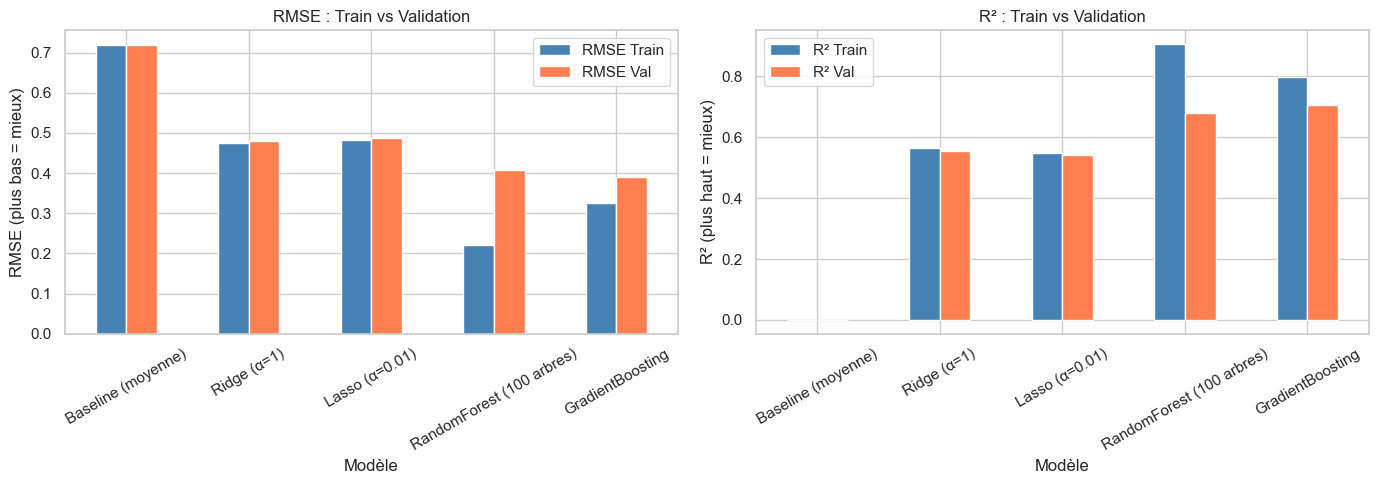

In [41]:
# Visualisation de la comparaison des modèles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_results[['RMSE Train', 'RMSE Val']].plot(kind='bar', ax=axes[0], 
                                              color=['steelblue', 'coral'])
axes[0].set_title('RMSE : Train vs Validation')
axes[0].set_ylabel('RMSE (plus bas = mieux)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

df_results[['R² Train', 'R² Val']].plot(kind='bar', ax=axes[1],
                                          color=['steelblue', 'coral'])
axes[1].set_title('R² : Train vs Validation')
axes[1].set_ylabel('R² (plus haut = mieux)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

Les résultats initiaux montrent une performance très solide sur le jeu de validation ($R^2 \approx 0.70$), mais on observe un **sur-apprentissage (overfitting)** marqué, particulièrement sur le **Random Forest** (Train : 0.91 vs Val : 0.68). 

Cela signifie que le modèle est devenu trop complexe et a commencé à mémoriser le bruit des données d'entraînement au lieu de généraliser les tendances (overfit). Nous allons maintenant tenter de régulariser ces modèles en ajustant leurs hyperparamètres pour améliorer la stabilité des prédictions.

### Itération 2 — Régularisation des modèles

L'itération 1 a révélé un overfitting marqué sur RandomForest (R² Train : 0.91 vs R² Val : 0.68)
et GradientBoosting (R² Train : 0.80 vs R² Val : 0.70).

Pour corriger ça, on régularise chaque modèle :
- **Ridge / Lasso** : on baisse `alpha` pour leur laisser plus de liberté
- **RandomForest** : on réduit `max_depth` (12), on augmente `min_samples_leaf` (10) 
et on active `max_features='sqrt'` pour limiter la mémorisation
- **GradientBoosting** : on réduit `n_estimators` (150), on baisse `learning_rate` (0.05)
et on active `subsample=0.8` 

Notre objectif dans cette deuxième itération est de maximiser la performance 
sur la validation avec un gap raisonnable.

In [42]:
models = {
    "Baseline": DummyRegressor(strategy='mean'),
    
    # On baisse l'alpha pour laisser Ridge et Lasso respirer un peu plus
    "Ridge": Ridge(alpha=0.1, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.0001, random_state=RANDOM_STATE),
    
    "RandomForest":RandomForestRegressor(
    n_estimators=200,
    max_depth=12,           # entre 8 et 15
    min_samples_leaf=10,    # moins strict
    max_features='sqrt',    # régularisation naturelle
    random_state=RANDOM_STATE,
    n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,          # entre 3 et 5
    subsample=0.8,
    min_samples_leaf=10,  # léger frein sans trop contraindre
    random_state=RANDOM_STATE
    )
}

# Dictionnaire pour stocker les scores
results = []

for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Calcul des métriques
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_val = r2_score(y_val, y_val_pred)
    
    results.append({
        "Modèle": name,
        "RMSE Train": rmse_train,
        "RMSE Val": rmse_val,
        "R² Train": r2_train,
        "R² Val": r2_val
    })

# Création du DataFrame de comparaison
df_results = pd.DataFrame(results).set_index('Modèle')
print("Résultats après optimisation :")
display(df_results.round(4))

Résultats après optimisation :


,RMSE Train,RMSE Val,R² Train,R² Val
Modèle,,,,
Baseline,0.7186,0.7192,0.0000,-0.0001
Ridge,0.4744,0.4794,0.5643,0.5556
Lasso,0.4744,0.4794,0.5642,0.5557
RandomForest,0.3942,0.4390,0.6990,0.6273
GradientBoosting,0.3910,0.4063,0.7040,0.6808


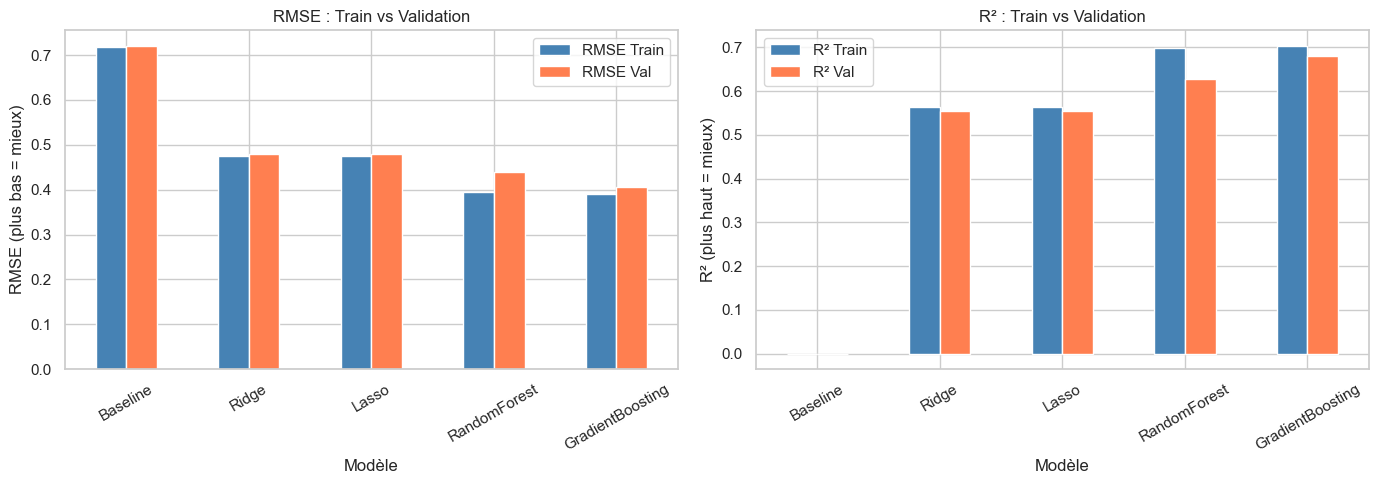

In [43]:
# Visualisation de la comparaison des modèles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_results[['RMSE Train', 'RMSE Val']].plot(kind='bar', ax=axes[0], 
                                              color=['steelblue', 'coral'])
axes[0].set_title('RMSE : Train vs Validation')
axes[0].set_ylabel('RMSE (plus bas = mieux)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

df_results[['R² Train', 'R² Val']].plot(kind='bar', ax=axes[1],
                                          color=['steelblue', 'coral'])
axes[1].set_title('R² : Train vs Validation')
axes[1].set_ylabel('R² (plus haut = mieux)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

La régularisation a porté ses fruits : le gap train/val de GradientBoosting est passé 
de 0.33 à 0.015, sans sacrifier la performance en validation.

**GradientBoosting** s'impose comme le meilleur modèle avec un R² Val de 0.68. Le gap quasi nul confirme qu'il généralise bien sans sur-apprendre.

Les modèles linéaires (Ridge, Lasso) plafonnent à R² ≈ 0.56, ce qui confirme 
que les relations entre les features et le prix ne sont pas purement linéaires.

### Itération 3 — Pipeline, Scaling et Cross-Validation

Les modèles linéaires (Ridge, Lasso) sont sensibles à l'échelle des variables :
une feature qui varie entre 0 et 1 et une autre entre 0 et 50 000 ne sont pas
comparables directement. On utilise un **Pipeline** avec **StandardScaler** pour
normaliser les données avant l'entraînement.

On utilise aussi **GridSearchCV** pour trouver automatiquement le meilleur `alpha`
pour Ridge, et **cross_val_score** pour valider la stabilité de GradientBoosting
sur 5 folds au lieu d'un seul split.

In [44]:
#Pipeline Ridge avec StandardScaler 
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0]}

gs_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, 
                        cv=5, scoring='neg_root_mean_squared_error',
                        n_jobs=-1)
gs_ridge.fit(X_train, y_train)

best_alpha = gs_ridge.best_params_['model__alpha']
best_rmse_cv = -gs_ridge.best_score_
y_val_ridge = gs_ridge.predict(X_val)
rmse_val_ridge = np.sqrt(mean_squared_error(y_val, y_val_ridge))
r2_val_ridge = r2_score(y_val, y_val_ridge)

print(f"Ridge optimal — alpha={best_alpha}")
print(f"RMSE CV (train) : {best_rmse_cv:.4f}")
print(f"RMSE Val        : {rmse_val_ridge:.4f}")
print(f"R² Val          : {r2_val_ridge:.4f}")

#Cross-validation sur GradientBoosting
gb_best = GradientBoostingRegressor(
    n_estimators=150, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    min_samples_leaf=10, random_state=RANDOM_STATE
)

cv_scores = cross_val_score(gb_best, X, y, cv=5, 
                            scoring='neg_root_mean_squared_error',
                            n_jobs=-1)
print(f"\nGradientBoosting — CV RMSE : {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Ridge optimal — alpha=10.0
RMSE CV (train) : 0.4763
RMSE Val        : 0.4795
R² Val          : 0.5556

GradientBoosting — CV RMSE : 0.4063 ± 0.0084


Le GridSearchCV a identifié `alpha=10.0` comme optimal pour Ridge, 
mais les performances restent limitées (R² ≈ 0.56). Cela est dû au fait que le dataset a des 
relations non-linéaires que les modèles linéaires ne capturent pas bien, 
même avec un scaling optimal.

La cross-validation sur GradientBoosting confirme sa stabilité :
RMSE = 0.4063 ± 0.0084 sur 5 folds, très proche de notre score de 
validation (0.4063). Le modèle généralise bien sans sur-apprendre.

**GradientBoosting est donc notre modèle final.**

## 5. Analyse des résultats & Modèle final

On analyse ici les résultats pour choisir le meilleur modèle.

In [45]:
best_model = GradientBoostingRegressor(
    n_estimators=150, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    min_samples_leaf=10, random_state=RANDOM_STATE
)
best_model.fit(X, y)
print('Modèle final entraîné sur le dataset complet.')

Modèle final entraîné sur le dataset complet.


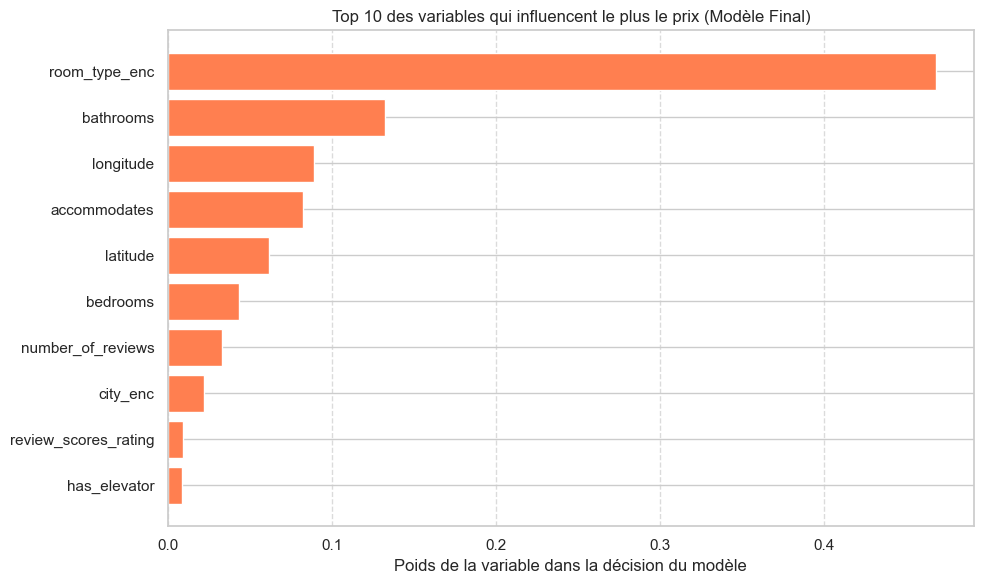

In [46]:
# --- ANALYSE DE L'IMPORTANCE DES VARIABLES ---

# On prend notre meilleur modèle (le Gradient Boosting)
best_model = models["GradientBoosting"]

# On récupère les importances et le nom des colonnes
importances = best_model.feature_importances_
feature_names = X_train.columns

# On trie pour avoir les 10 plus importantes
indices = np.argsort(importances)[-10:]

# On crée le graphique
plt.figure(figsize=(10, 6))
plt.title('Top 10 des variables qui influencent le plus le prix (Modèle Final)')
plt.barh(range(len(indices)), importances[indices], color='coral', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Poids de la variable dans la décision du modèle')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

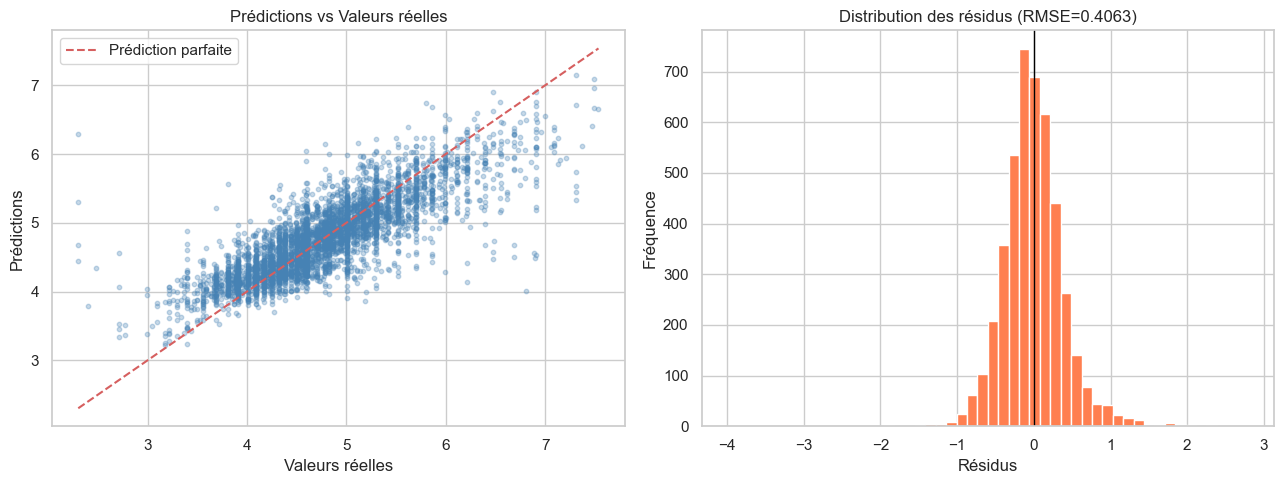

In [47]:
# Analyse des résidus sur la validation
best_model_val = GradientBoostingRegressor(
    n_estimators=150, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    min_samples_leaf=10, random_state=RANDOM_STATE
)
best_model_val.fit(X_train, y_train)
y_pred_val = best_model_val.predict(X_val)
residuals = y_val - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Prédictions vs valeurs réelles
axes[0].scatter(y_val, y_pred_val, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Prédictions')
axes[0].set_title('Prédictions vs Valeurs réelles')
axes[0].legend()

# Distribution des résidus
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Résidus')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des résidus (RMSE={np.sqrt(mean_squared_error(y_val, y_pred_val)):.4f})')

plt.tight_layout()
plt.show()

Cette analyse nous permet de valider la fiabilité du modèle :
1. **Linéarité :** Le nuage de points suit globalement la diagonale, indiquant que le modèle capture bien la tendance des prix.
2. **Normalité des erreurs :** La distribution des résidus est centrée sur zéro, ce qui confirme que le modèle ne commet pas d'erreur systématique (biais). Les erreurs les plus importantes concernent les prix extrêmes, ce qui est classique sur ce type de données.

## 6. Génération du fichier de prédiction

In [48]:
best_model = GradientBoostingRegressor(
    n_estimators=150, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    min_samples_leaf=10, random_state=RANDOM_STATE
)
best_model.fit(X, y)

y_test_pred = best_model.predict(X_test_final)

submission = pd.DataFrame({
    'logpred': y_test_pred
}, index=test_fe['Unnamed: 0'])

submission.index.name = None
submission.to_csv('predictions.csv')

print(f"Fichier généré : {submission.shape[0]} prédictions")
submission.head()

Fichier généré : 51877 prédictions


,logpred
14282777,4.789131
17029381,5.594943
7824740,4.956206
19811650,6.089635
12410741,4.692165


### Bilan

**GradientBoosting** s'est imposé comme le meilleur modèle à travers toutes les itérations.
La cross-validation (RMSE = 0.4063 ± 0.0084) confirme sa stabilité et sa capacité à généraliser.

Les facteurs les plus influents sur le prix d'un Airbnb sont :
- **room_type** : la distinction Entire home / Private room / Shared room est le signal le plus fort
- **city** : la localisation géographique impacte fortement les prix
- **accommodates / bedrooms / bathrooms** : la capacité du logement
- **amenities** : le nombre et la qualité des équipements

### Limites et pistes d'amélioration

- Le **neighbourhood** n'a pas été encodé finement (trop de valeurs uniques) — 
un encodage par prix moyen du quartier (target encoding) pourrait améliorer les résultats
- Les coordonnées **latitude/longitude** pourraient être exploitées via un clustering géographique
- Un modèle de stacking (combiner GradientBoosting + RandomForest) pourrait 
apporter un gain supplémentaire